## Atividade aula 16

1. Carregar e pré-processar os dados (parte 1)
– Carregar o conjunto de dados CSV em um
DataFrame (por exemplo, com a biblioteca
pandas).
– Verificar se há valores ausentes ou inconsistências e, se houver, decidir como tratá-los
(remoção, imputação etc.).
– Normalizar todas as variáveis para que tenham média zero e variância unitária. Isso é
fundamental para que o SOM trate cada dimensão de forma equitativa.
2. Treinar o SOM (parte 2)
– Definir o tamanho do mapa (por exemplo, uma grade 10×10 de neurônios).
– Inicializar o SOM (podendo utilizar bibliotecas como
MiniSom ou outra abordagem).
– Treinar o SOM, iterando pelos dados. Ajustar parâmetros como
learning rate,
sigma (raio
de vizinhança) e o número de iterações.
3. Visualizar e interpretar os clusters (parte 3)
– Mapear cada cliente para o neurônio vencedor (BMU –
Best Matching Unit) no SOM.
– Criar um gráfico bidimensional (correspondente às coordenadas do mapa) para visualizar
onde cada cliente se localiza.
– Identificar regiões do mapa que concentram clientes com padrões de gasto semelhantes.
– Discutir possíveis ações de marketing para cada grupo ou região do mapa. Por exemplo,
clientes com alto gasto em eletrônicos podem receber campanhas focadas em
tecnologia; clientes com gasto equilibrado em todas as categorias podem receber ofertas
diversificadas etc.

In [2]:
%pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=a086ecbc7666ab2ad06168099468c1d25f13edac544ba122c44dbb1fc9a0be1c
  Stored in directory: /root/.cache/pip/wheels/19/db/95/5e53bc2b88a328217fdf9f2886cafbe86b0df274f4b601f572
Successfully built minisom


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from minisom import MiniSom

# Carregar dados
df = pd.read_csv('/content/14.1 - customer_data.csv')

# Verificar os dados
print(df.head())
print(df.info())

# Verificar valores ausentes
print(df.isnull().sum())

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(df.values)


   ID  Renda Anual  Gastos em Roupas  Gastos em Alimentos  \
0   1        40000              5000                 6000   
1   2        52000              7000                 8000   
2   3        30000              3000                 4000   
3   4        60000              9000                10000   
4   5        45000              5000                 6000   

   Gastos em Eletrônicos  Gastos em Saúde  
0                   1500             2000  
1                   3000             4000  
2                   1000             1500  
3                   5000             7000  
4                   2000             3000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   ID                     100 non-null    int64
 1   Renda Anual            100 non-null    int64
 2   Gastos em Roupas       100 non-null    int64
 3   Gastos em A

Verificado que não há valores nulos

In [25]:
# Inicializar o SOM (tamanho do mapa 10x10, dimensões de entrada iguais ao número de colunas)
som = MiniSom(x=10, y=10, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X)
som.train_random(X, num_iteration=100)

<ipython-input-26-418388f9f1e3>:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_result, x='x', y='y', s=100, alpha=0.7, palette='viridis')


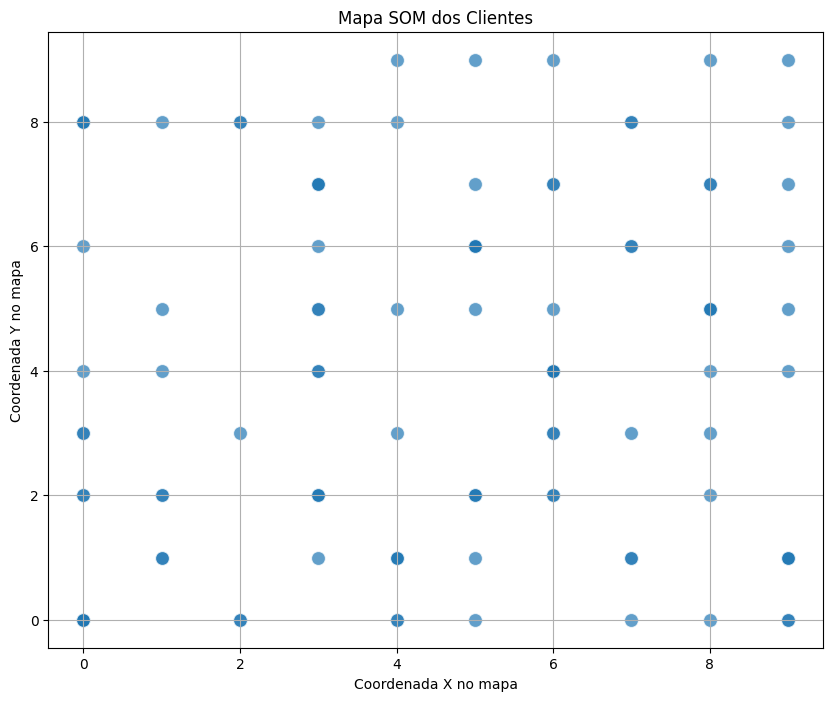

In [26]:
# Mapear cada cliente para a posição (x, y) no SOM
coordinates = np.array([som.winner(x) for x in X])
df_result = pd.DataFrame(coordinates, columns=['x', 'y'])

# Juntar os dados normalizados (opcional para análise futura)
df_result = pd.concat([df_result, pd.DataFrame(X, columns=df.columns)], axis=1)

# Visualizar os clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_result, x='x', y='y', s=100, alpha=0.7, palette='viridis')
plt.title('Mapa SOM dos Clientes')
plt.xlabel('Coordenada X no mapa')
plt.ylabel('Coordenada Y no mapa')
plt.grid(True)
plt.show()

Por padrão, o SOM não identifica os clusters como o K-means, nesse caso precisa fazer separadamente a idenfiticação dos BMUs (Best Matching Units)

In [27]:
# Mapeia cada cliente para o BMU
winner_coordinates = np.array([som.winner(x) for x in X])

# Agrupa os clientes pelo BMU (x, y)
df_result = pd.DataFrame(winner_coordinates, columns=['x', 'y'])

In [28]:
# Codifica as coordenadas (x, y) como IDs de clusters únicos
df_result['cluster'] = df_result['x'].astype(str) + '-' + df_result['y'].astype(str)

# Opcional: aplicar um LabelEncoder para deixar os clusters numéricos
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_result['cluster_id'] = le.fit_transform(df_result['cluster'])

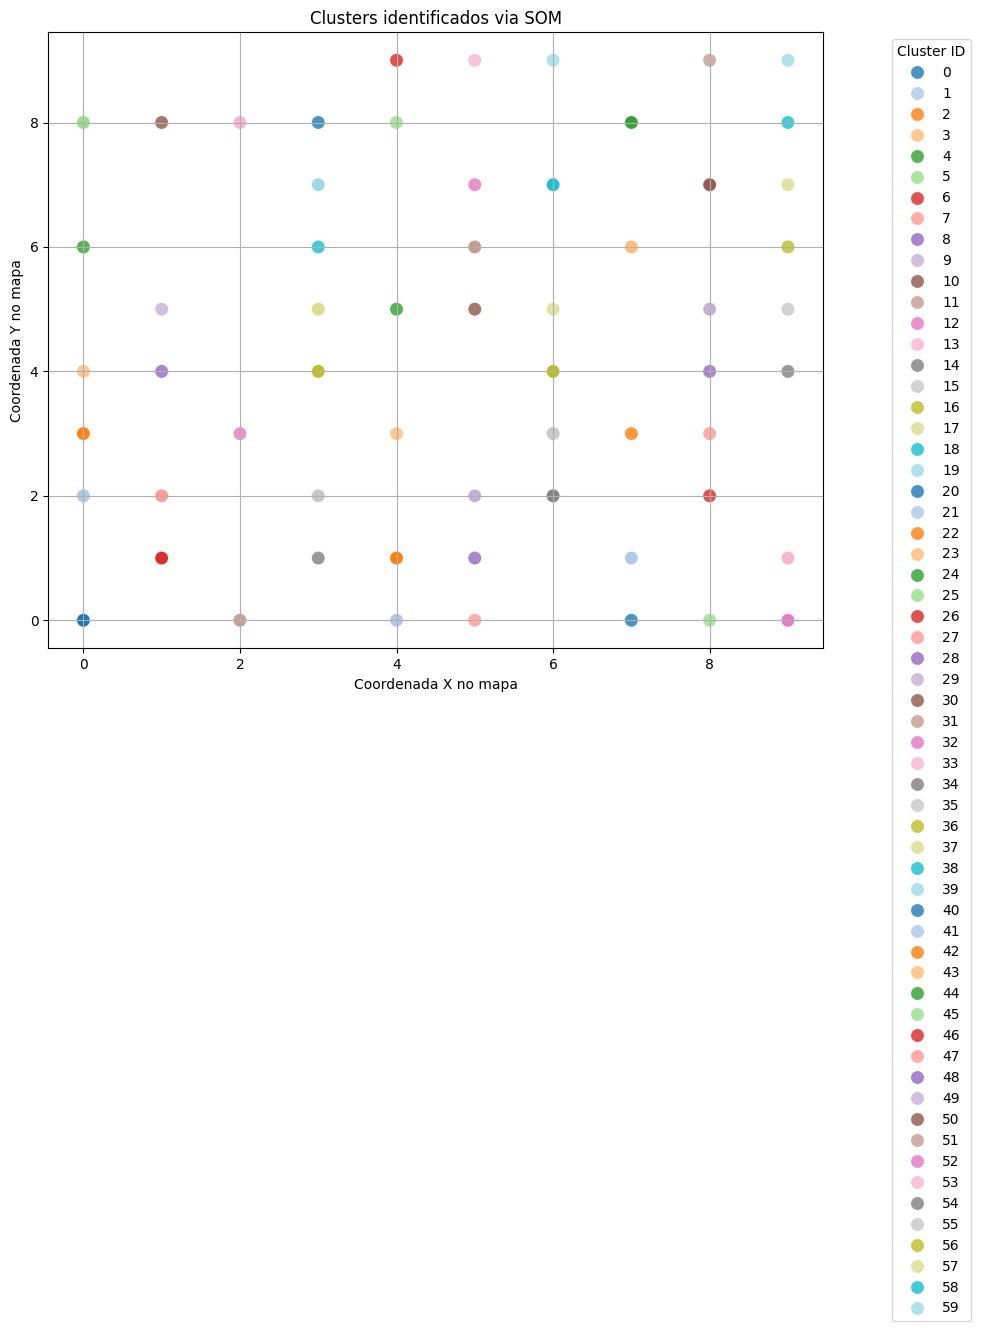

In [29]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_result, x='x', y='y', hue='cluster_id', palette='tab20', s=100, alpha=0.8)
plt.title('Clusters identificados via SOM')
plt.xlabel('Coordenada X no mapa')
plt.ylabel('Coordenada Y no mapa')
plt.grid(True)
plt.legend(title="Cluster ID", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

## Utilizando uma matriz menor com menos "neurônios" (5x5)

In [13]:
som = MiniSom(x=5, y=5, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X)
som.train_random(X, num_iteration=100)

In [16]:
# Mapear cada cliente para a posição (x, y) no SOM
coordinates = np.array([som.winner(x) for x in X])
df_result = pd.DataFrame(coordinates, columns=['x', 'y'])

# Juntar os dados normalizados (opcional para análise futura)
df_result = pd.concat([df_result, pd.DataFrame(X, columns=df.columns)], axis=1)

# Mapeia cada cliente para o BMU
winner_coordinates = np.array([som.winner(x) for x in X])

# Agrupa os clientes pelo BMU (x, y)
df_result = pd.DataFrame(winner_coordinates, columns=['x', 'y'])

# Codifica as coordenadas (x, y) como IDs de clusters únicos
df_result['cluster'] = df_result['x'].astype(str) + '-' + df_result['y'].astype(str)

# Opcional: aplicar um LabelEncoder para deixar os clusters numéricos
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_result['cluster_id'] = le.fit_transform(df_result['cluster'])

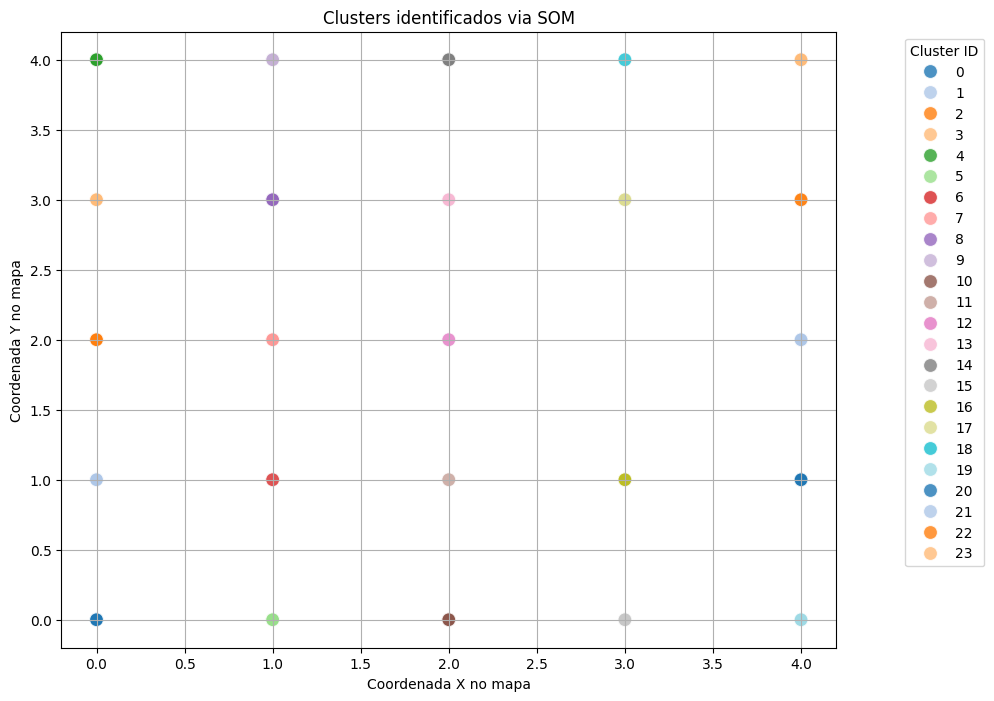

In [20]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_result, x='x', y='y', hue='cluster_id', palette='tab20', s=100, alpha=0.8)
plt.title('Clusters identificados via SOM')
plt.xlabel('Coordenada X no mapa')
plt.ylabel('Coordenada Y no mapa')
plt.grid(True)
plt.legend(title="Cluster ID", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()